# School Visualizations: Urban Informatics Final Project

Spring 2026

**Contributors:** Anwar Baroudi, Phoebe Chiu, Noelani Fixler, Michael Huang

### **1. setup, install packages**

In [1]:
import os, base64, requests
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.ticker import FormatStrFormatter
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.stats import pearsonr
from statsmodels.stats.proportion import proportions_ztest
import researchpy as rp
from census import Census

#### a) load data

In [3]:
# github connections
GITHUB_RAW = 'https://github.com/MiAnPh/MAPN-SRTS/raw/main/data'

# EPC tracts (2018 ACS)
mtc_epcs = gpd.read_file(f'{GITHUB_RAW}/raw/equity_priority_communities_2020_acs2018.zip')
mtc_epcs.columns = mtc_epcs.columns.str.strip().str.lower().str.replace(' ', '_')

# Schools
ac_public_schools  = gpd.read_file(f'{GITHUB_RAW}/processed/proj_schools_public.geojson')
ac_private_schools = gpd.read_file(f'{GITHUB_RAW}/processed/proj_schools_private.geojson')
ac_schools_all     = gpd.read_file(f'{GITHUB_RAW}/processed/proj_schools_all.geojson')

# 2024 Alameda County tracts
ac_mtc_epcs_acs5_24 = gpd.read_file(f'{GITHUB_RAW}/processed/alameda_county_tracts.geojson')

print('mtc_epcs:         ', mtc_epcs.shape)
print('ac_schools_all:   ', ac_schools_all.shape)
print('ac_public_schools:', ac_public_schools.shape)
print('ac_mtc_epcs_acs5_24:', ac_mtc_epcs_acs5_24.shape)

mtc_epcs:          (339, 40)
ac_schools_all:    (150, 50)
ac_public_schools: (122, 97)
ac_mtc_epcs_acs5_24: (379, 14)


#### b) flag schools & tracts as EPC / Non-EPC*

In [4]:
# EPC union geometry
epc_union   = mtc_epcs.geometry.unary_union
epc_geoids  = mtc_epcs['geoid'].unique()

# tag schools
ac_schools_all  = ac_schools_all.reset_index(drop=True)
ac_schools_all['within_epc'] = ac_schools_all.geometry.within(epc_union)

# tag 2024 tracts
ac_mtc_epcs_acs5_24['epc'] = ac_mtc_epcs_acs5_24['GEOID'].isin(epc_geoids)

# Alameda County-only MTC EPCs
ac_mtc_epcs = mtc_epcs[mtc_epcs['county_fip'] == '001']
ac_mtc_epcs_acs5_24 = ac_mtc_epcs_acs5_24[ac_mtc_epcs_acs5_24['epc'] == True].to_crs(ac_mtc_epcs.crs)

print('EPC tracts (2018):', ac_mtc_epcs.shape)
print('EPC tracts (2024):', ac_mtc_epcs_acs5_24.shape)
print('Schools tagged:',   ac_schools_all['within_epc'].value_counts().to_dict())

EPC tracts (2018): (101, 40)
EPC tracts (2024): (97, 15)
Schools tagged: {True: 150}


/var/folders/h_/3yf49mgn3ss4ysbnt4n3wyk00000gn/T/ipykernel_55187/3975722772.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  epc_union   = mtc_epcs.geometry.unary_union


### **2. Gathering ACS Data**

#### a) direct download (2018 ACS — EPC baseline)

In [5]:
non_epcs_raw = pd.read_csv(
    f'{GITHUB_RAW}/processed/ACSDT5Y2018.vehicle_ownership-Data.csv',
    skiprows=1
)

non_epcs_raw = non_epcs_raw.rename(columns={
    'Geography': 'geo_id_full',
    'Estimate!!Total': 'total_households',
    'Estimate!!Total!!Owner occupied!!No vehicle available': 'owner_no_vehicle',
    'Estimate!!Total!!Renter occupied!!No vehicle available': 'renter_no_vehicle'
})

non_epcs_raw['geoid'] = non_epcs_raw['geo_id_full'].str[-11:]
for col in ['total_households', 'owner_no_vehicle', 'renter_no_vehicle']:
    non_epcs_raw[col] = pd.to_numeric(non_epcs_raw[col], errors='coerce')

non_epcs_raw['zero_vehicle_households'] = non_epcs_raw['owner_no_vehicle'] + non_epcs_raw['renter_no_vehicle']
non_epcs_raw['pct_zvhhs'] = np.where(
    non_epcs_raw['total_households'] > 0,
    non_epcs_raw['zero_vehicle_households'] / non_epcs_raw['total_households'],
    np.nan
)

non_epcs_df = non_epcs_raw[~non_epcs_raw['geoid'].isin(epc_geoids)][['geoid', 'pct_zvhhs']].dropna()

# combined EPC / Non-EPC dataframe for plotting
epc_zvhhs         = mtc_epcs[['geoid', 'pct_zvhhs']].copy(); epc_zvhhs['type'] = 'EPC'
non_epc_zvhhs     = non_epcs_df.copy();                       non_epc_zvhhs['type'] = 'Non-EPC'
combined_zvhhs    = pd.concat([epc_zvhhs, non_epc_zvhhs])
display(combined_zvhhs.head())

,geoid,pct_zvhhs,type
0,06001401000,0.264453,EPC
1,06001401300,0.333149,EPC
2,06001401400,0.272208,EPC
3,06001401500,0.321296,EPC
4,06001401600,0.180876,EPC


In [52]:
# input a Census API key to continue

api_key = input()
c = Census(key=api_key)
c

 test


#### b) Census API (2024 ACS)

In [ ]:


census_zvhhs_vars = {
    'NAME': 'NAME', 'GEO_ID': 'GEO_ID',
    'B08201_001E': 'total',    'B08201_001M': 'total_moe',
    'B08201_002E': 'no_vehicle', 'B08201_002M': 'no_vehicle_moe',
}

ac_zvhhs = pd.DataFrame(
    cc.acs5.get(list(census_zvhhs_vars.keys()),
               {'for': 'tract:*', 'in': 'state:06 county:001'}, year=2024)
)
ac_zvhhs.rename(columns=census_zvhhs_vars, inplace=True)
ac_zvhhs['geoid'] = ac_zvhhs['GEO_ID'].astype(str).str[9:]
ac_zvhhs['epc']   = ac_zvhhs['geoid'].isin(epc_geoids)

# proportions + MOEs
ac_zvhhs['pct_zvhhs']     = ac_zvhhs['no_vehicle'] / ac_zvhhs['total']
ac_zvhhs['pct100_zvhhs']  = ac_zvhhs['pct_zvhhs'] * 100
ac_zvhhs['pct_zvhhs_moe'] = (
    ((ac_zvhhs['no_vehicle_moe']**2)
     - (ac_zvhhs['pct_zvhhs']**2) * (ac_zvhhs['total_moe']**2)) ** 0.5
    / ac_zvhhs['total']
)

# EPC label column
ac_zvhhs['type'] = np.where(
    ac_zvhhs['epc'], 'Equity Priority Community', 'Non-Equity Priority Community'
)

ac_epcs_zvhhs     = ac_zvhhs[ac_zvhhs['epc'] == True]
ac_non_epcs_zvhhs = ac_zvhhs[ac_zvhhs['epc'] == False]

print(ac_zvhhs.shape)
ac_zvhhs.head(2)

#### c) verify EPC geometries

In [ ]:
#visual check: 2018 MTC EPCs (blue) vs 2024 census tracts (red)
m = ac_mtc_epcs.explore(color='blue', name='MTC EPCs 2014-2018')
ac_mtc_epcs_acs5_24.explore(m=m, color='red', name='Updated 2024 Census Geometry')
m

### **3. Run Functions**

In [55]:
from functions import mtc_colors, plot_distribution_and_mean_ci

# below I am typing the functions I want to use and the code will run them
print(mtc_colors)
plot_distribution_and_mean_ci


{'Equity Priority Community': '#fb2739', 'Non-Equity Priority Community': '#285b8e'}


<function functions.plot_distribution_and_mean_ci(df, y_col, x_col, title_prefix, x_label, y_label_boxplot, y_label_pointplot, filename_prefix, palette, ylim_multiplier=1.1)>

### **4. Prepare Student Demographics**

In [ ]:
# Spatial join: public schools → 2024 EPC tracts
if 'index_right' in ac_public_schools.columns:
    ac_public_schools = ac_public_schools.drop(columns=['index_right'])

epc_pub_schools = gpd.sjoin(ac_public_schools, ac_mtc_epcs_acs5_24, how='inner', predicate='within')
non_epc_pub_schools = ac_public_schools.loc[
    ~ac_public_schools.index.isin(epc_pub_schools.index)
].copy()

epc_pub_schools['location_type']     = 'Inside EPC'
non_epc_pub_schools['location_type'] = 'Outside EPC'

# Students of color %
race_cols = ['AApct', 'AIpct', 'ASpct', 'FIpct', 'HIpct', 'PIpct']
for df in [epc_pub_schools, non_epc_pub_schools]:
    df['pocpct'] = df[race_cols].sum(axis=1)

# POC count + pct (Phoebe's method)
bipoc_count_cols = ['AAcount', 'AIcount', 'AScount', 'FIcount', 'HIcount', 'PIcount']
ac_public_schools['POC_count']  = ac_public_schools[bipoc_count_cols].sum(axis=1)
ac_public_schools['poc_pct_v2'] = ac_public_schools['POC_count'] / ac_public_schools['EnrollTotal']
ac_public_schools['Type'] = ac_public_schools.geometry.within(epc_union).map({
    True:  'Equity Priority Community',
    False: 'Non-Equity Priority Community'
})

# Combined df for simple boxplots
combined_demographics = pd.concat([
    epc_pub_schools[['SchoolName', 'pocpct', 'SEDpct', 'location_type']],
    non_epc_pub_schools[['SchoolName', 'pocpct', 'SEDpct', 'location_type']]
])

display(combined_demographics.head())


,SchoolName,pocpct,SEDpct,location_type
0,Envision Academy for Arts & Technology,86.0,78.9,Inside EPC
1,Community School for Creative Education,90.9,91.9,Inside EPC
2,Yu Ming Charter,70.9,31.8,Inside EPC
3,Alameda County Juvenile Hall/Court,97.8,100.0,Inside EPC
4,Alternatives in Action,100.0,95.5,Inside EPC


### **5. Visualizations**

#### a) School Types: Countywide vs. EPCs

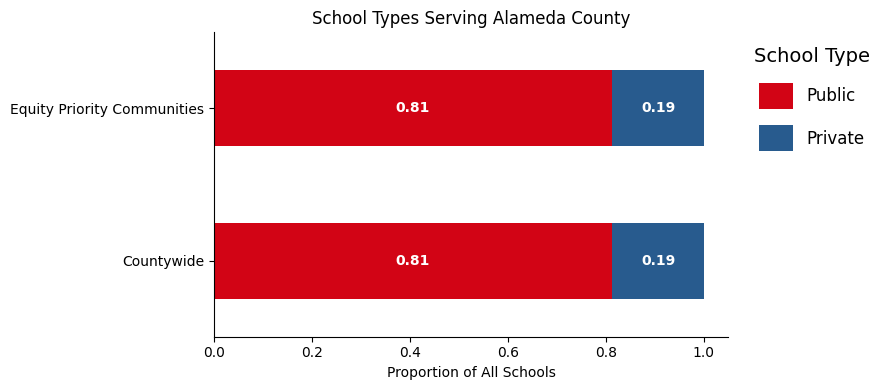

In [ ]:
all_counts = ac_schools_all['Type'].value_counts()
epc_counts = ac_schools_all[ac_schools_all['within_epc']]['Type'].value_counts()

counts = pd.DataFrame({'Countywide': all_counts, 'Equity Priority Communities': epc_counts}).fillna(0)
counts = counts.reindex(['Public', 'Private'])
props  = counts / counts.sum(axis=0)

fig, ax = plt.subplots(figsize=(9, 4))
props.T.plot(kind='barh', stacked=True, ax=ax, color=['#d20415', '#285b8e'])
ax.set_xlabel('Proportion of All Schools')
ax.set_title('School Types Serving Alameda County')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(title='School Type', bbox_to_anchor=(1.02, 1), loc='upper left',
          frameon=False, fontsize=12, title_fontsize=14, labelspacing=1,
          handlelength=2, handleheight=2)

for i, row in enumerate(props.T.values):
    cumulative = 0
    for val in row:
        if val > 0:
            ax.text(cumulative + val/2, i, f'{val:.2}',
                    ha='center', va='center', color='white', fontsize=10, fontweight='bold')
        cumulative += val

plt.tight_layout()
plt.savefig('alameda_school_types.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

#### b) Zero Vehicle Households

##### **i) Simple Boxplot (2018 ACS baseline)**

/tmp/ipykernel_3237/4215432913.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='pct_zvhhs', data=combined_zvhhs,


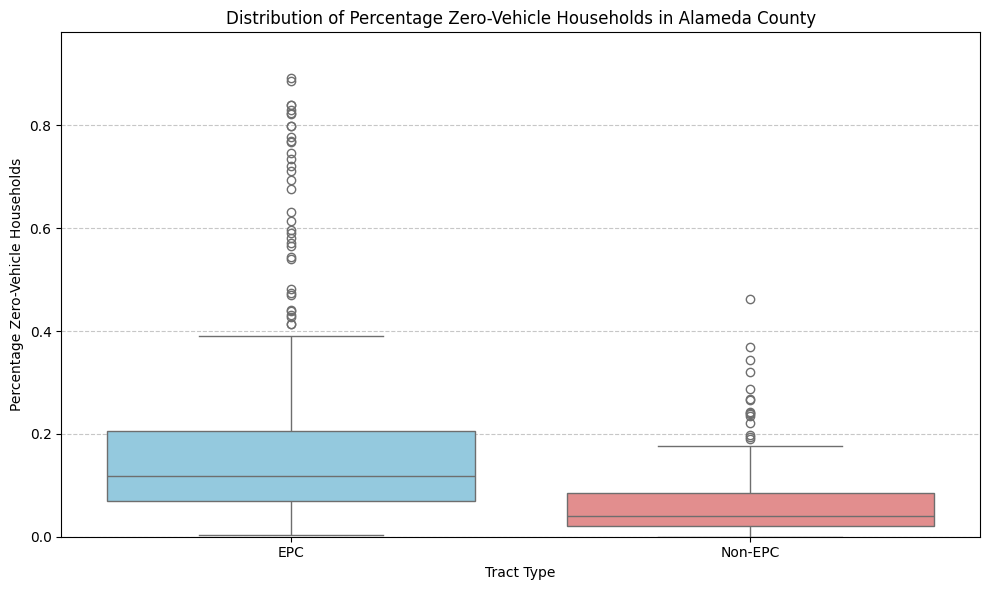

In [ ]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='pct_zvhhs', data=combined_zvhhs,
            palette={'EPC': 'skyblue', 'Non-EPC': 'lightcoral'})
plt.title('Distribution of Percentage Zero-Vehicle Households in Alameda County')
plt.xlabel('Tract Type')
plt.ylabel('Percentage Zero-Vehicle Households')
plt.ylim(0, combined_zvhhs['pct_zvhhs'].max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('alameda_zvhhs_baseline_bxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

##### **ii) Boxplot + 95% CI (2024 ACS)**

In [ ]:
filenames_zvhhs = plot_distribution_and_mean_ci(
    df=ac_zvhhs,
    y_col='pct_zvhhs',
    x_col='type',
    title_prefix='Zero Vehicle Households',
    x_label='Tract Type',
    y_label_boxplot='Proportion of Households Without a Vehicle in a Census Tract',
    y_label_pointplot='Proportion of Zero Vehicle Households',
    filename_prefix='../outputs/visuals/alameda_zvhhs_tracts',
    palette=mtc_colors
)
print('saved:', filenames_zvhhs)

saved: ['alameda_zvhhs_tracts_pct_zvhhs_bxplot.png', 'alameda_zvhhs_tracts_pct_zvhhs_95CI.png']


##### **iii) Statistical Test**

In [ ]:
# t-test: EPC vs Non-EPC zero vehicle households
rp.ttest(ac_epcs_zvhhs.pct_zvhhs, ac_non_epcs_zvhhs.pct_zvhhs)

/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:301: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'pct_zvhhs' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table.iloc[0,0] = group1_name
/usr/local/lib/python3.12/dist-packages/researchpy/ttest.py:460: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Difference (pct_zvhhs - pct_zvhhs) = ' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  table2.iloc[0,0] = f"Difference ({group1_name} - {group2_name}) = "


(    Variable      N      Mean        SD        SE  95% Conf.  Interval
 0  pct_zvhhs   97.0  0.165569  0.131344  0.013336   0.139098  0.192041
 1  pct_zvhhs  280.0  0.082604  0.101665  0.006076   0.070644  0.094564
 2   combined  377.0  0.103950  0.115727  0.005960   0.092231  0.115670,
                       Independent t-test   results
 0  Difference (pct_zvhhs - pct_zvhhs) =     0.0830
 1                  Degrees of freedom =   375.0000
 2                                   t =     6.4001
 3               Two side test p value =     0.0000
 4              Difference < 0 p value =     1.0000
 5              Difference > 0 p value =     0.0000
 6                           Cohen's d =     0.7540
 7                           Hedge's g =     0.7525
 8                      Glass's delta1 =     0.6317
 9                    Point-Biserial r =     0.3138)

In [ ]:
ac_zvhhs.groupby('type')['pct_zvhhs'].describe()

,count,mean,std,min,25%,50%,75%,max
type,,,,,,,,
Equity Priority Community,97.0,0.165569,0.131344,0.005447,0.078871,0.125225,0.198373,0.767658
Non-Equity Priority Community,280.0,0.082604,0.101665,0.000000,0.022212,0.049473,0.104950,0.756150


##### **iv) Population Pyramid Data Prep**

In [ ]:
dist_bins   = list(range(0, 80, 2))
dist_labels = list(range(0, 78, 2))

counts_ac_epcs     = pd.cut(ac_epcs_zvhhs['pct100_zvhhs'],     bins=dist_bins, labels=dist_labels).value_counts().sort_index()
counts_ac_non_epcs = pd.cut(ac_non_epcs_zvhhs['pct100_zvhhs'], bins=dist_bins, labels=dist_labels).value_counts().sort_index()


#### c) Student Demographics

##### **i) Students of Color**

/tmp/ipykernel_3237/1699265992.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_demographics, x='location_type', y='pocpct', palette='Set2')


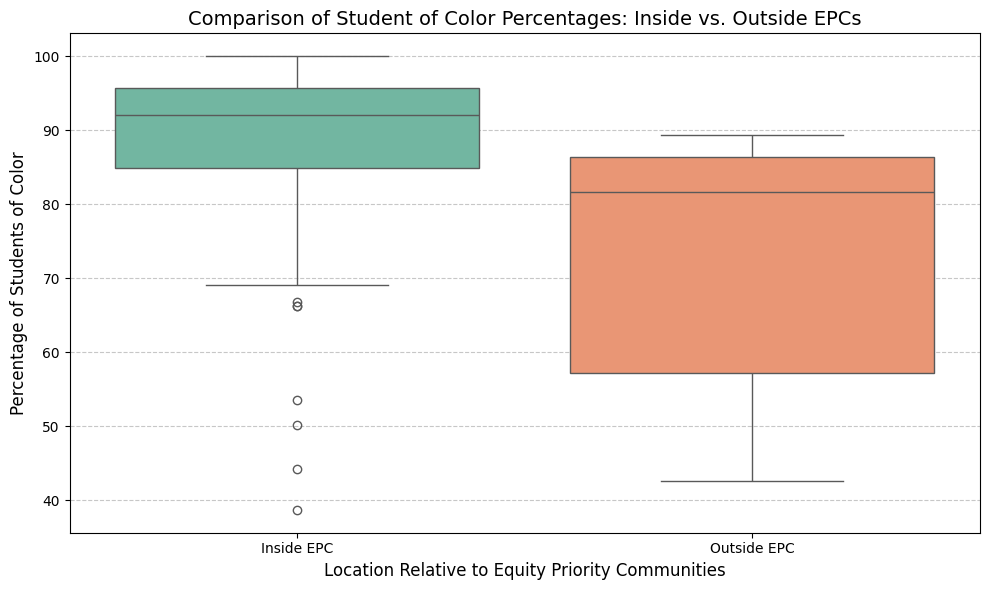

In [ ]:
# V1 — simple palette (Set2)
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_demographics, x='location_type', y='pocpct', palette='Set2')
plt.title('Comparison of Student of Color Percentages: Inside vs. Outside EPCs', fontsize=14)
plt.xlabel('Location Relative to Equity Priority Communities', fontsize=12)
plt.ylabel('Percentage of Students of Color', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ac_students_poc_set2_bxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# V2 — MTC colors + 95% CI point plot
filenames_poc = plot_distribution_and_mean_ci(
    df=ac_public_schools,
    y_col='poc_pct_v2',
    x_col='Type',
    title_prefix='BIPOC Students',
    x_label='School Location',
    y_label_boxplot='Proportion of School Population who are BIPOC',
    y_label_pointplot='Proportion of School Population who are BIPOC',
    filename_prefix='../outputs/visuals/ac_students_poc',
    palette=mtc_colors
)
print('saved:', filenames_poc)

saved: ['ac_students_poc_poc_pct_v2_bxplot.png', 'ac_students_poc_poc_pct_v2_95CI.png']


##### **ii) Socioeconomically Disadvantaged Students**

/tmp/ipykernel_3237/2107724251.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined_demographics, x='location_type', y='SEDpct', palette='Pastel1')


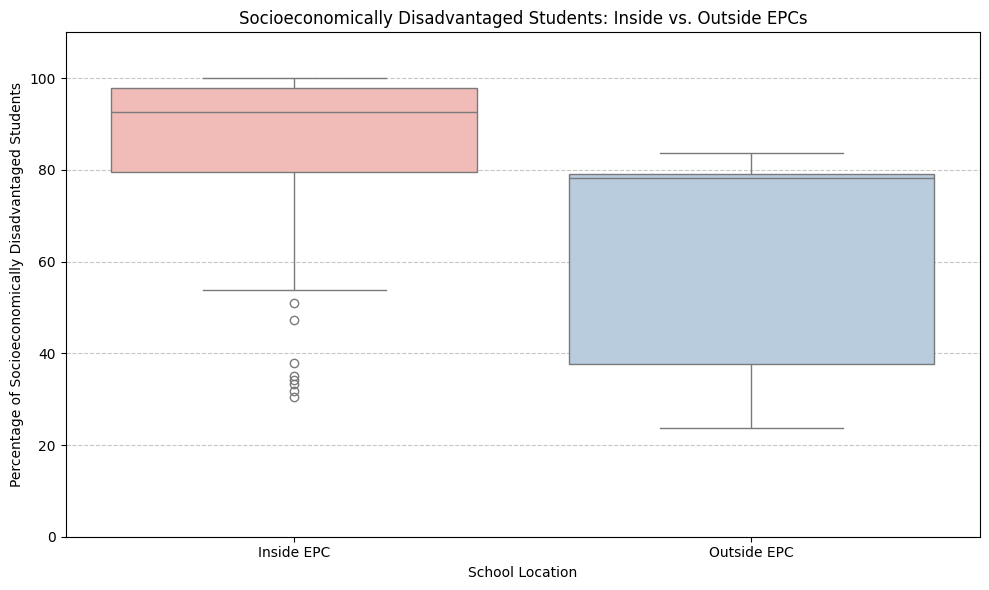

In [ ]:
# V1 — simple palette
plt.figure(figsize=(10, 6))
sns.boxplot(data=combined_demographics, x='location_type', y='SEDpct', palette='Pastel1')
plt.title('Socioeconomically Disadvantaged Students: Inside vs. Outside EPCs')
plt.xlabel('School Location')
plt.ylabel('Percentage of Socioeconomically Disadvantaged Students')
plt.ylim(0, combined_demographics['SEDpct'].max() * 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('ac_students_sed_pastel_bxplot.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

In [ ]:
# V2 — MTC colors + 95% CI point plot
filenames_sed = plot_distribution_and_mean_ci(
    df=ac_public_schools,
    y_col='SEDpct',
    x_col='Type',
    title_prefix='Socioeconomically Disadvantaged Students',
    x_label='School Location',
    y_label_boxplot='Proportion of School Population who are Socioeconomically Disadvantaged',
    y_label_pointplot='Percentage of School Population Who are \nSocioeconomically Disadvantaged (%)',
    filename_prefix='../outputs/visuals/ac_students_sed',
    palette=mtc_colors
)
print('saved:', filenames_sed)

saved: ['ac_students_sed_SEDpct_bxplot.png', 'ac_students_sed_SEDpct_95CI.png']


##### **iii) Students with Disabilities**

In [ ]:
filenames_swd = plot_distribution_and_mean_ci(
    df=ac_public_schools,
    y_col='SWDpct',
    x_col='Type',
    title_prefix='Students with Disabilities',
    x_label='School Location',
    y_label_boxplot='Proportion of School Population with a Disability',
    y_label_pointplot='Percentage of School Population Who\nHave a Disability (%)',
    filename_prefix='../outputs/visuals/ac_students_swd',
    palette=mtc_colors
)
print('saved:', filenames_swd)

saved: ['ac_students_swd_SWDpct_bxplot.png', 'ac_students_swd_SWDpct_95CI.png']
